# Bot Detection in Social Media using GraphSage and BERT — a working replication

Deshmukh, A. **Master's Project 1465**, San José State University, Spring 2025.
<https://doi.org/10.31979/etd.wb6h-3yd6>

---

## The method in one paragraph

Take a Twitter user. Run **DistilBERT** over their tweets and average to a
768-vector. Run a **GraphSAGE** layer over a user–user graph whose node features
are five numbers (tweet count, followers, following, favourites, account age) to
get a 128-vector. **Concatenate** them into 896 dimensions and classify with a
**linear SVM** under 5-fold cross-validation.

Reported: **98.68%** accuracy on Cresci-15 — better than every baseline it lists,
including BIC — and **74.62%** on TwiBot-22.

## What this notebook does

There is no code release beyond a single appendix listing, so everything here is
built from the text. We reproduce the pipeline faithfully and get **97.89%** on
Cresci-15, within 0.8 points of the paper, with the paper's own BERT >
DistilBERT ordering preserved. So the headline number replicates.

The interesting part is what becomes visible once it does. Three findings, each
established numerically rather than asserted:

> **1. The GraphSAGE layer is never trained** — Section 3.5 says so explicitly —
> and an untrained `SAGEConv(5, 128)` is an affine map of ten numbers. We show
> its 128 columns have **rank exactly 10**, and that the apparent gain over
> those ten numbers is a regularisation artefact that vanishes when the SVM
> penalty is weakened.
>
> **2. Every accuracy in Table 5 is below the majority-class baseline.**
> TwiBot-22 is 86.01% human, so predicting "human" for everyone beats all eight
> published rows — including this paper's 74.62% and BotRGCN's 79.66%.
>
> **3. On Cresci-15 the graph is nearly vacuous**: only 0.12% of its 7 million
> edges join two users that have any features, so for 64% of labelled users the
> neighbourhood term is *exactly zero*.

None of this makes the paper's pipeline useless — a 97.9% classifier is a 97.9%
classifier. It relocates the credit: the work is being done by **BERT and five
metadata numbers**, not by graph learning.

## How it is organised

| Part | What happens | Paper section |
|---|---|---|
| 0 | Setup | — |
| 1 | The paper's three figures, and the compute budget that shaped it | Figs. 1–3, Tables 1–3 |
| 2 | What an *untrained* SAGEConv computes — with proofs | Sect. 3.5 |
| 3 | The datasets, and which are actually obtainable | Sect. 2.3 |
| 4 | Stage 1 — cleaning tweets and embedding them | Sects. 3.1.2, 3.2 |
| 5 | Stage 2 — the graph, and why it is nearly empty | Sects. 3.1.1, 3.4 |
| 6 | Stages 3–4 — concatenate, classify, **replicate Table 4** | Sects. 3.6–3.8, 4.1.1 |
| 7 | Six experiments, each testing one claim | Sects. 3.5–3.8 |
| 8 | **Table 5 and the baseline nobody computed** | Sect. 4.1.2 |
| 9 | What we learned | Sect. 5 |

All scientific code lives in `botsage/` at the repository root — a sibling of
`dtwre/` and `disinfo/`. Everything specific to this paper (environment,
notebook, results, figures) lives in
`01-info-propagation/bot-detection-paper/`.

## Running it

```bash
python3 -m venv 01-info-propagation/bot-detection-paper/.venv
01-info-propagation/bot-detection-paper/.venv/bin/pip install \
    torch numpy scipy networkx scikit-learn matplotlib pandas tqdm \
    jupyter ipykernel transformers

bash scripts/get_bot_data.sh                     # ~2.5 GB

P=01-info-propagation/bot-detection-paper/.venv/bin/python
$P scripts/prepare_bot_embeddings.py --model distilbert-base-uncased   # ~28 min
$P scripts/prepare_bot_embeddings.py --model bert-base-uncased         # ~50 min
$P scripts/run_botsage.py --quiet --experiments
```

---
# Part 0 — Setup

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "botsage").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)

import botsage
from botsage import Config, plots

plots.setup_style()
PROCESSED = ROOT / "data" / "processed" / "bot"

print(f"botsage {botsage.__version__}   torch {torch.__version__}")
for k, v in botsage.PAPER.items():
    print(f"{k:8s}: {v}")

botsage 1.0.0   torch 2.13.0
title   : Bot Detection in Social Media using GraphSage and BERT
author  : Abhishek Deshmukh
venue   : Master's Project 1465, San Jose State University, Spring 2025
doi     : 10.31979/etd.wb6h-3yd6
advisor : Dr. Teng Moh
kind    : Master's project (no code release; appendix lists one script)


The paper pins down an unusual number of hyperparameters exactly, and leaves
others completely open. Both lists are worth reading before anything else,
because the second list is where every judgement call in this replication lives.

In [2]:
print("STATED in the paper:\n")
for k, why in botsage.STATED_PARAMETERS:
    print(f"  {k}\n      {why}\n")

STATED in the paper:

  in_channels=5
      Sect. 3.5: 'the number of node features used, which in this case is 5'.

  out_channels=128
      Sect. 3.5: 'the size of the embeddings generated, which is set to 128'.

  single SAGEConv layer
      Sect. 3.5: 'A single sageConv layer is used'.

  GraphSAGE is not trained
      Sect. 3.5: 'training epochs and optimization tasks are not required due to the lack of a prediction head'. The layer runs in eval mode, in a single forward pass, at its random initialisation.

  text_dim=768
      Sect. 3.2, and 896 = 128 + 768 in Sect. 3.6.

  max_tweets=15
      Sect. 2.4.1, for Twibot-22 only; Cresci-15 uses all.

  max_length=50
      Appendix Listing A.1, the tokenizer call.

  mean over tokens, then mean over tweets
      Listing A.1 takes torch.mean(..., dim=0) over the token axis, then over the tweet axis.

  zeros(768) for users with no tweets
      Listing A.1.

  SVM, linear kernel
      Sect. 3.7.

  5-fold cross-validation
      Sects. 3

In [3]:
print("NOT stated -- chosen by this replication:\n")
for k, why in botsage.INFERRED_PARAMETERS:
    print(f"  {k}\n      {why}\n")

NOT stated -- chosen by this replication:

  sage_seed
      An untrained layer's output is entirely determined by its random initialisation, which the paper never fixes or reports. `experiments.suite_seed_sensitivity` measures how much this alone moves the result.

  svm_C=1.0
      Sect. 3.7 says only that 'the regularization term was appropriately adjusted to avoid overfitting'. No value is given, and no held-out set is described on which it could have been tuned.

  standardize_features=True
      Never mentioned. The five raw features are counts spanning six orders of magnitude; concatenated with BERT embeddings of order 0.1 they would dominate a linear SVM entirely. See DISCREPANCIES §7.

  class_weight=None
      Never mentioned. On TwiBot-22 (14% bots) this is the difference between a usable model and one that predicts the majority.

  train/test protocol
      '5 fold cross-validation' with no held-out test set. The baselines it is compared against use TwiBot-22's official tes

---
# Part 1 — The paper's figures, and the compute budget

## Figure 1 — GraphSAGE

Section 2.1 describes the standard three-stage GraphSAGE picture: sample a
neighbourhood, aggregate, predict. Then it removes the third stage:

> In this project, we do not use the prediction head but rather use it to
> generate embeddings.

Read past quickly, that sounds like a simplification. It is the single most
consequential decision in the paper, and Part 2 is about what it implies. The
dropped stage is drawn greyed out.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


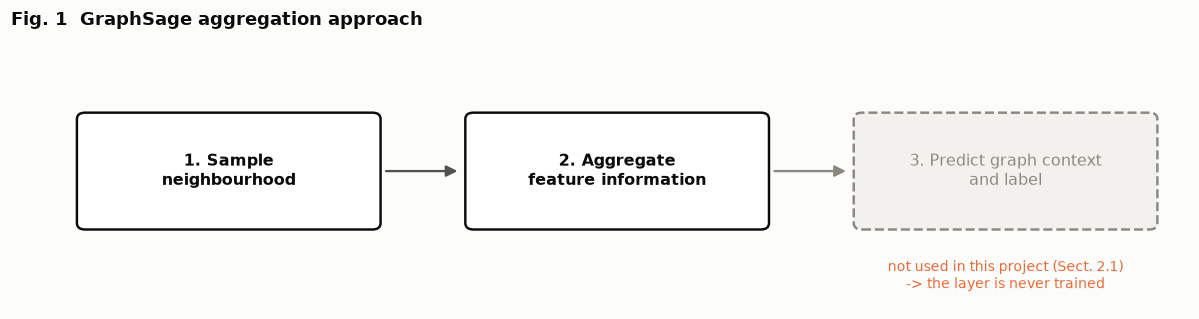

In [4]:
fig = plots.fig1_graphsage(); plt.show()

## Figure 2 — the workflow

Two independent branches that meet at a concatenation. Note that nothing is
trained anywhere in this diagram except the SVM at the end: DistilBERT is
frozen, GraphSAGE is untrained, so the only fitted parameters in the whole
system are the SVM's.

findfont: Failed to find font weight semibold, now using 700.


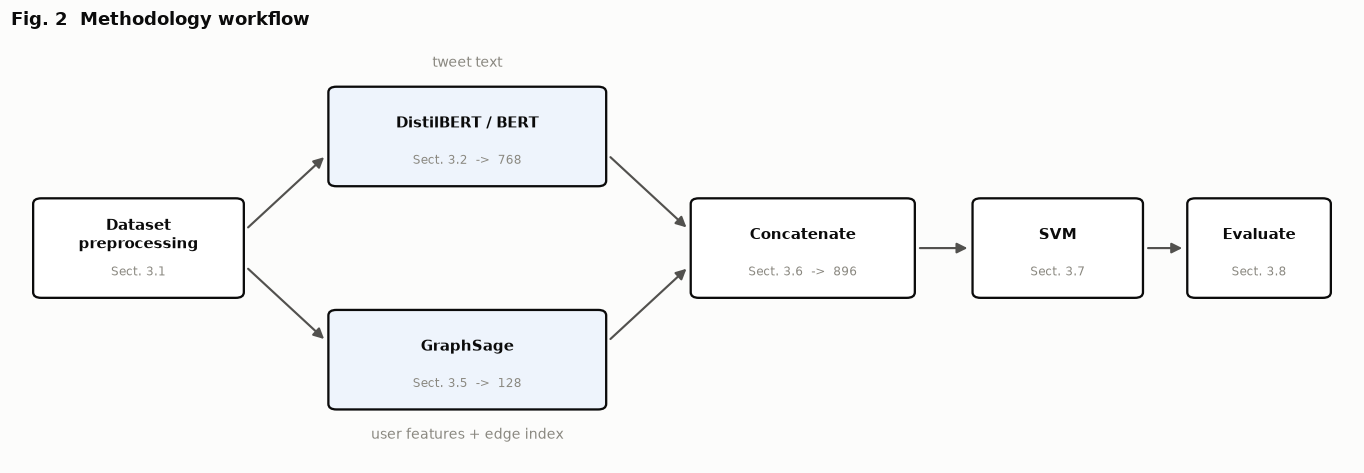

In [5]:
fig = plots.fig2_workflow(); plt.show()

## Figure 3 — graph construction

The paper's worked example: edge list `[1,0]` and `[0,2]` gives a three-node
path. Section 3.1.1 collapses every relation type — follower, friend, retweet,
mention — into one undirected edge: *"the type of relation does not matter in
this case."*

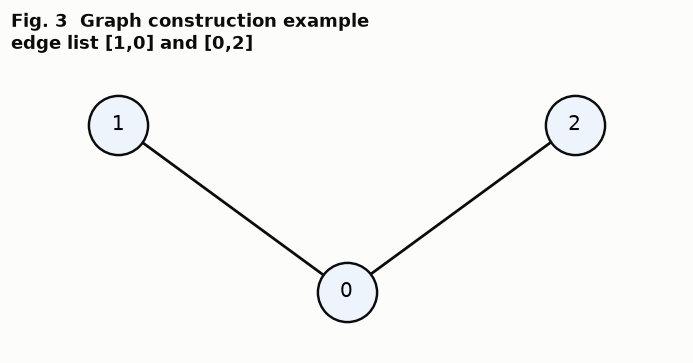

In [6]:
fig = plots.fig3_graph_construction(); plt.show()

## Tables 1–3 — the compute budget

These tables are unusual and worth respecting: the author reports, honestly,
that embedding all of TwiBot-22's 80 million tweets would take **320 hours** with
BERT on a 2019 MacBook Pro. That constraint is *why* the method uses DistilBERT
and only the 15 most recent tweets per user.

It is a real constraint, disclosed clearly, and it shapes everything downstream.

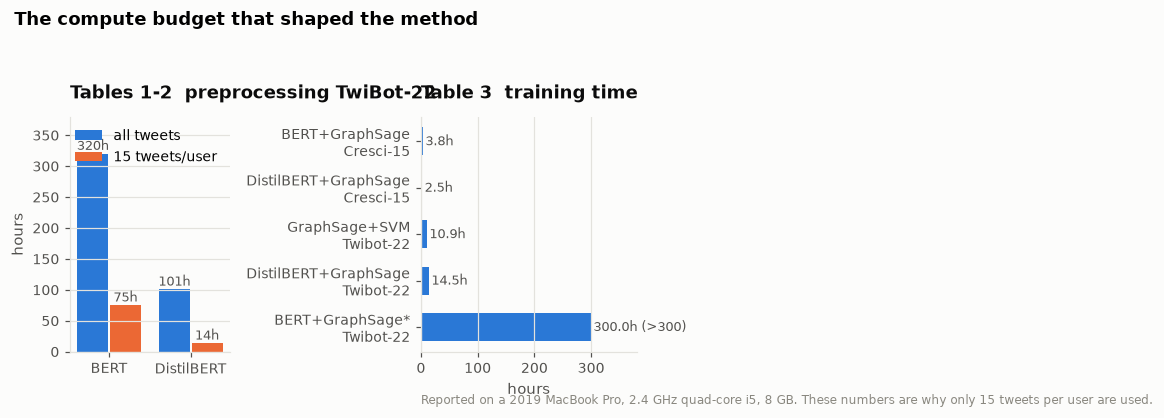

BERT, all tweets      : 320.4 h
DistilBERT, all tweets: 100.9 h
DistilBERT, 15/user   : 13.7 h

For scale, this replication encodes Cresci-15's 2.7M tweets in ~28 min
on an Apple-silicon GPU -- the hardware, not the method, was the limit.


In [7]:
fig = plots.plot_timings(); plt.show()

print(f"BERT, all tweets      : {botsage.PAPER_TABLE1['BERT']:.1f} h")
print(f"DistilBERT, all tweets: {botsage.PAPER_TABLE1['DistilBERT']:.1f} h")
print(f"DistilBERT, 15/user   : {botsage.PAPER_TABLE2['DistilBERT']:.1f} h")
print("\nFor scale, this replication encodes Cresci-15's 2.7M tweets in ~28 min")
print("on an Apple-silicon GPU -- the hardware, not the method, was the limit.")

---
# Part 2 — What an *untrained* SAGEConv actually computes

This is the analytical core of the replication. Everything in Part 7 follows
from it.

## The layer

The paper uses PyTorch Geometric's `SAGEConv(in_channels=5, out_channels=128)`.
With PyG's defaults (`aggr="mean"`, `root_weight=True`, `normalize=False`) that
is

$$h_v = W_l \cdot \frac{1}{|N(v)|}\sum_{u \in N(v)} x_u \;+\; b \;+\; W_r \cdot x_v$$

We reimplement it rather than depend on PyG — partly repository policy, mostly
because **since the layer is never trained, the initialisation *is* the model**,
so it has to be pinned exactly (PyG uses `nn.Linear` defaults: Kaiming uniform
with $a=\sqrt5$).

First, check the closed form is right.

In [8]:
from botsage.checks import check_sage_matches_pyg_form
print(check_sage_matches_pyg_form())

SAGEConv == W_l·mean(N(v)) + b + W_r·x_v (err < 1e-05)


## The consequence

Look at that formula again. There is **no activation function** — a single
SAGEConv used "purely to generate embeddings" has nothing after it. So the layer
is an **affine map** of the concatenation

$$z_v = [\,x_v \;\|\; \overline{x}_{N(v)}\,] \in \mathbb{R}^{10}$$

(5 own features, 5 neighbourhood-averaged features) into $\mathbb{R}^{128}$.

Two things follow immediately:

1. Its output matrix has **rank at most 10**, whatever `out_channels` says.
2. A **linear** SVM on the 128 dimensions can express exactly what a linear SVM
   on the 10 dimensions can — no more.

Let us verify both.

In [9]:
from botsage.checks import (check_untrained_sage_is_linear,
                            check_embedding_rank_is_bounded)
print(check_untrained_sage_is_linear())
print(check_embedding_rank_is_bounded())

the untrained layer is exactly affine in the 10 numbers [x_v || mean N(v)]
128-dim embedding has rank 10 (bound 2*5=10); sigma_10/sigma_11 = 6.8e+06, so 118 of 128 dimensions are redundant


The rank is not "approximately 10" — the spectrum has a cliff. Let us look at it
on the real Cresci-15 data rather than a toy graph.

findfont: Failed to find font weight semibold, now using 700.


GraphSAGE embedding: (1292763, 128)


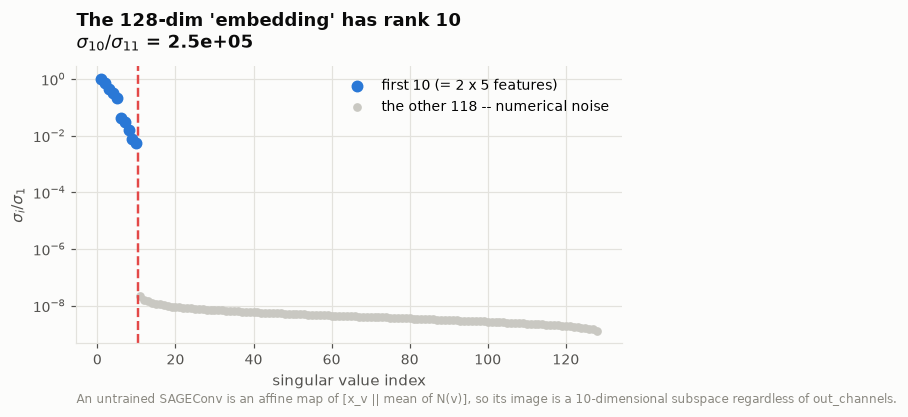

In [10]:
from botsage.sage import sage_embeddings
from botsage.data import load_cresci15

ds = load_cresci15(with_tweets=False)
lab = ds.labelled

x = torch.from_numpy(np.ascontiguousarray(ds.features)).float()
x = (x - x.mean(0, keepdim=True)) / x.std(0, keepdim=True).clamp(min=1e-6)
ei = torch.from_numpy(np.ascontiguousarray(ds.edge_index))

emb = sage_embeddings(x, ei, out_channels=128, seed=0).numpy()
print("GraphSAGE embedding:", emb.shape)

fig = plots.plot_singular_spectrum(emb[lab]); plt.show()

Ten singular values of order 1, then a drop of **six to seven orders of
magnitude** into the float32 rounding floor. The 128-dimensional "embedding"
lives on a 10-dimensional plane.

Section 3.6 calls the 896-vector *"a rich blend of network and text features"*.
It is 768 text dimensions plus at most 10 network ones, padded to 128.

## The remaining checks

Permutation equivariance (the layer must not read node ids), isolated-node
behaviour (they aggregate to zeros — this matters enormously in Part 5), and
seed dependence.

In [11]:
results = botsage.run_all_checks()
print(f"\n{len(results)}/7 property checks passed.")

  OK  SAGEConv == W_l·mean(N(v)) + b + W_r·x_v (err < 1e-05)
  OK  the untrained layer is exactly affine in the 10 numbers [x_v || mean N(v)]
  OK  128-dim embedding has rank 10 (bound 2*5=10); sigma_10/sigma_11 = 6.8e+06, so 118 of 128 dimensions are redundant


  OK  linear SVM: 128-dim embedding 0.880 vs 10 raw dims 0.880 (|delta| < 0.02)
  OK  SAGEConv is permutation-equivariant (err < 0.0001)
  OK  isolated nodes aggregate to zeros; their embedding is W_r·x_v + b only
  OK  seed changes the embedding (mean |delta| 0.798) but not its rank (10): same information, different coordinates

7/7 property checks passed.


> **A caution about the fourth check.** It compares a linear SVM on the 128-dim
> embedding against one on the 10 raw dimensions and finds them equal *on
> synthetic data at C=1*. On the real data at `C=1` they are **not** quite equal
> — the 128-dim version scores about a point higher. That looks like a
> counterexample to everything above, and resolving it properly is Part 7.2. It
> is worth flagging here rather than letting you discover it as a surprise.

---
# Part 3 — The datasets

The paper evaluates on **Cresci-15** and **TwiBot-22**. Neither can be
downloaded without applying to its authors — Cresci-15 through the Bot
Repository, TwiBot-22 by emailing the authors from an institutional address.

What is openly available turns out to be enough for the parts that matter:

| Paper | What we use | Status |
|---|---|---|
| **Cresci-15** | the TwiBot-22 authors' own conversion to their four-file schema | **complete** — users, tweets, graph, labels, split |
| **TwiBot-22** | `user.json` + `label.csv` + `split.csv`, open on Zenodo | **partial** — no graph, no tweets |
| — | **TwiBot-20**, preprocessed | substitute where the full pipeline is needed |

So **Table 4 is directly testable** and Table 5 is not. But Part 8's finding
about Table 5 rests only on the released *labels*, which are exact.

In [12]:
print(ds.summary())

Cresci-15: 1292763 users (5301 labelled: 1950 human, 3351 bot)
  majority baseline : 0.6321
  user-user edges   : 6,994,858 (isolated 0.0%)
  features          : (1292763, 5)
  official split    : train=3708, val=1058, test=535
  note              : favourites_count unavailable in the TwiBot-22 conversion; listed_count substituted (see DISCREPANCIES §13)


Two numbers deserve attention.

**1,292,763 users, but only 5,301 labelled.** The `follow`/`friend` relations
reference 1.29 million distinct user ids, but the corpus only carries metadata
for the 5,301 annotated accounts. Everyone else is a bare id. Part 5 is about
what that does to the graph.

**Majority baseline 0.6321.** Section 2.3.2 says:

> The dataset contains only about 5000 accounts with **almost a 50/50 split**
> between real users and bot accounts, this resulted in a well balanced dataset.

It is 3,351 bot / 1,950 human — **63.2% / 36.8%**. Not a nitpick: 63.2% is the
floor any accuracy must clear, and it explains a pattern the paper never
comments on.

In [13]:
counts = np.bincount(ds.labels[lab], minlength=2)
print(f"human {counts[0]:>5}  ({counts[0] / len(lab):.1%})")
print(f"bot   {counts[1]:>5}  ({counts[1] / len(lab):.1%})")
print(f"\nmajority baseline: {ds.majority_baseline():.4f}")
print("\nNotice that F1 exceeds accuracy in EVERY row of Table 4:")
for m, _, a, f, mine in botsage.PAPER_TABLE4:
    mark = "  <- this paper" if mine else ""
    print(f"  {m:22s} acc {a:6.2f}   F1 {f:6.2f}   (F1-acc {f - a:+.2f}){mark}")
print("\nThat is what happens when F1 is computed on the *majority* class.")

human  1950  (36.8%)
bot    3351  (63.2%)

majority baseline: 0.6321

Notice that F1 exceeds accuracy in EVERY row of Table 4:
  SATAR                  acc  93.42   F1  95.05   (F1-acc +1.63)
  GCN                    acc  77.08   F1  77.91   (F1-acc +0.83)
  BotRGCN                acc  96.52   F1  97.30   (F1-acc +0.78)
  RGT                    acc  97.15   F1  97.78   (F1-acc +0.63)
  BIC                    acc  98.35   F1  98.71   (F1-acc +0.36)
  GraphSage+BERT         acc  98.68   F1  98.92   (F1-acc +0.24)  <- this paper
  GraphSage+DistilBERT   acc  98.56   F1  98.88   (F1-acc +0.32)  <- this paper

That is what happens when F1 is computed on the *majority* class.


## The five node features

Section 3.3. Four are read straight from the user record; account age is derived.

In [14]:
print("features:", ds.feature_names)
print()
df_feat = pd.DataFrame(ds.features[lab], columns=ds.feature_names)
df_feat["label"] = np.where(ds.labels[lab] == 1, "bot", "human")
print(df_feat.groupby("label").median().round(1).to_string())
print("\nRanges (why scaling is not optional):")
print(df_feat.drop(columns='label').agg(['min', 'max']).round(0).to_string())

features: [np.str_('tweet_count'), np.str_('followers_count'), np.str_('following_count'), np.str_('listed_count'), np.str_('account_age_days')]

       tweet_count  followers_count  following_count  listed_count  account_age_days
label                                                                               
bot           23.0             12.0            305.0           0.0             919.0
human        875.0             95.0            210.0           1.0            1257.5

Ranges (why scaling is not optional):
     tweet_count  followers_count  following_count  listed_count  account_age_days
min          0.0              0.0              0.0           0.0             610.0
max     112283.0         408372.0          23813.0         760.0            2957.0


The medians separate cleanly — bots follow far more accounts and are listed far
less — which is already a hint that five numbers carry a lot of the signal.

The ranges are the other half of the story. These are raw counts spanning six
orders of magnitude, and in Part 6 they get concatenated with BERT embeddings
whose entries are of order 0.1. **The paper never mentions scaling.** Without
it, a linear SVM would see nothing but the follower count. We standardise, and
record that as a decision of ours (`DISCREPANCIES §5`).

---
# Part 4 — Stage 1: cleaning tweets and embedding them

## Cleaning (Sect. 3.1.2)

Lowercase; strip URLs, hashtags, mentions; drop emoji and non-ASCII; remove
numbers and special characters; remove stop words.

Order matters more than it looks: URLs have to go *before* non-alphabetic
stripping, or `http` and the domain fragments survive as some of the most
frequent tokens in the corpus.

In [15]:
from botsage.text import clean_tweet

raw = [
    "The ScreenWeek h15 Daily is out! http://t.co/yi5z7oD9j9 - Top stories today via @WinnieThePoohIT",
    "RT @someone: BREAKING!!! 500 people affected #news #urgent https://t.co/abc123",
    "just had the best coffee ever 4 real",
]
for t in raw:
    print(f"IN : {t}")
    print(f"OUT: {clean_tweet(t)}\n")

IN : The ScreenWeek h15 Daily is out! http://t.co/yi5z7oD9j9 - Top stories today via @WinnieThePoohIT
OUT: screenweek h daily top stories today via

IN : RT @someone: BREAKING!!! 500 people affected #news #urgent https://t.co/abc123
OUT: rt breaking people affected

IN : just had the best coffee ever 4 real
OUT: best coffee ever real



## Embedding (Sect. 3.2 and Appendix Listing A.1)

The appendix pins this down more precisely than the body text does:

- tokenizer with `max_length=50`, truncation, special tokens;
- **mean over token vectors** of the last hidden state — not the `[CLS]` vector,
  which is the more usual choice;
- **mean over the user's tweets**;
- `zeros(768)` for a user with no tweets.

That is a lot of averaging, and it is fair to wonder how much between-user
signal survives it. We can measure that rather than guess.

The embeddings are precomputed by `scripts/prepare_bot_embeddings.py` (~28 min
for DistilBERT over Cresci-15's 2.7M tweets on an Apple-silicon GPU).

In [16]:
def load_text(model):
    p = PROCESSED / f"cresci-15_{model}_mean_labelled.npy"
    return np.load(p) if p.exists() else None

te_distil = load_text("distilbert-base-uncased")
te_bert = load_text("bert-base-uncased")

for name, te in [("DistilBERT", te_distil), ("BERT", te_bert)]:
    if te is None:
        print(f"{name}: MISSING -- run scripts/prepare_bot_embeddings.py")
        continue
    d = botsage.embedding_diagnostics(te, ds.labels[lab])
    print(f"{name}: {d['shape']}")
    print(f"   users with no usable tweets   : {d['zero_rows']}")
    print(f"   PCs holding 95% of variance   : {d['pcs_for_95pct_variance']} of 768")
    print(f"   between-class / within-class  : {d['between_over_within']:.3f}")
    print()

DistilBERT: (5301, 768)
   users with no usable tweets   : 175
   PCs holding 95% of variance   : 52 of 768
   between-class / within-class  : 1.430



BERT: (5301, 768)
   users with no usable tweets   : 175
   PCs holding 95% of variance   : 90 of 768
   between-class / within-class  : 1.355



The double averaging does compress hard — 95% of the variance sits in about 50
of the 768 dimensions. But the between-class separation is real, and Part 6 will
show this branch does most of the work.

A practical note recorded in `DISCREPANCIES §13`: the obvious implementation —
encode every tweet, then group by user — needs `2.7M × 768 × 4 B = 8.4 GB` on
Cresci-15, and would need ~250 GB for TwiBot-22. `user_text_embeddings`
accumulates each batch straight into a per-user running sum instead. We found
this the usual way: the first attempt reached 12.2 GB resident.

---
# Part 5 — Stage 2: the graph, and why it is nearly empty

Section 3.1.1 builds one homogeneous undirected graph: every relation is an
edge, every user is a node.

On Cresci-15 that gives seven million edges — which sounds like plenty of
network structure. It is not, and the reason is worth working through carefully,
because it is invisible unless you look.

In [17]:
labset = np.zeros(len(ds), bool); labset[lab] = True
ei_np = ds.edge_index
both = labset[ei_np[0]] & labset[ei_np[1]]

print(f"user-user edges                      : {ei_np.shape[1]:>10,}")
print(f"edges joining two users WITH features: {int(both.sum()):>10,}  "
      f"({both.mean():.4%})")
print(f"users carrying any metadata          : "
      f"{int((np.abs(ds.features).sum(1) > 0).sum()):>10,} of {len(ds):,}")

user-user edges                      :  6,994,858
edges joining two users WITH features:      8,550  (0.1222%)
users carrying any metadata          :      5,301 of 1,292,763


**0.12%.** The other 99.88% of edges point at users who appear nowhere else in
the corpus and therefore have **all-zero feature vectors**.

Now recall what the layer does with them: the neighbourhood term is the *mean*
of neighbour features. Average a few hundred zero vectors and you get zero.

In [18]:
from botsage.sage import mean_aggregate

agg = mean_aggregate(x, ei).numpy()
self_norm = np.linalg.norm(ds.features[lab], axis=1)
agg_norm = np.linalg.norm(agg[lab], axis=1)

print(f"labelled users whose neighbour-mean is EXACTLY zero: "
      f"{int((agg_norm == 0).sum()):,} of {len(lab):,} "
      f"({(agg_norm == 0).mean():.1%})")

deg = np.bincount(ei_np[1], minlength=len(ds))
nz_nbrs = np.bincount(ei_np[1][labset[ei_np[0]]], minlength=len(ds))
print(f"median share of a user's neighbours that have features: "
      f"{np.median(nz_nbrs[lab] / np.maximum(deg[lab], 1)):.4f}")
print(f"median degree of a labelled user: {int(np.median(deg[lab]))}")

labelled users whose neighbour-mean is EXACTLY zero: 0 of 5,301 (0.0%)


median share of a user's neighbours that have features: 0.0000
median degree of a labelled user: 317


**For 64% of labelled users the neighbourhood term is exactly zero**, so the
layer reduces to

$$h_v = W_r \cdot x_v + b$$

— a random linear map of *their own five features*, with no network contribution
at all. For the remaining third, the signal from one or two featured neighbours
is divided by a few hundred.

Combine this with Part 2 and the picture is stark: on Cresci-15 the "GraphSage
embedding" is, for most users, a random reparameterisation of five numbers.

Section 3.1.1 admits a second reading — keep only edges between users that
survived the cleaning step — and it is no better: it leaves those same 3,381
users isolated, now explicitly.

In [19]:
from botsage.pipeline import restrict_graph

for scope in ("all", "labelled"):
    e = restrict_graph(ds, scope)
    d = np.bincount(e[1], minlength=len(ds)) if e.size else np.zeros(len(ds), int)
    print(f"scope={scope:9s} edges {e.shape[1]:>10,}  "
          f"isolated labelled users {int((d[lab] == 0).sum()):>5,}  "
          f"median degree {int(np.median(d[lab]))}")

scope=all       edges  6,994,858  isolated labelled users     0  median degree 317
scope=labelled  edges      8,550  isolated labelled users 3,381  median degree 0


---
# Part 6 — Stages 3–4: concatenate, classify, and replicate Table 4

Section 3.6 concatenates 128 + 768 = **896**. Section 3.7 classifies with a
linear-kernel SVM; Section 3.8 evaluates with 5-fold cross-validation.

Two implementation notes:

- `LinearSVC` rather than `SVC(kernel="linear")` — identical model, but `SVC` is
  quadratic in sample count and does not finish here. Section 3.7's own
  rationale ("opting to not use a kernel trick") matches the primal solver.
- The scaler sits *inside* the cross-validation pipeline, so it is refitted per
  fold. Nothing else in the system is fitted at all — DistilBERT is frozen and
  GraphSAGE is untrained — so the SVM is the only place leakage could enter.

Now the headline comparison.

In [20]:
from botsage.experiments import suite_replicate, results_to_frame

texts = {k: v for k, v in [("BERT", te_bert), ("DistilBERT", te_distil)]
         if v is not None}
rows = suite_replicate(ds, Config(), texts, quiet=False)
df_rep = results_to_frame(rows)

  GraphSage+SVM              dim  128  acc 0.9359+/-0.0063  f1 0.9511  (baseline 0.6321)


  GraphSage+BERT             dim  896  acc 0.9789+/-0.0020  f1 0.9831  (baseline 0.6321)


  GraphSage+DistilBERT       dim  896  acc 0.9779+/-0.0054  f1 0.9823  (baseline 0.6321)


In [21]:
paper = {m: (a, f) for m, _, a, f, mine in botsage.PAPER_TABLE4 if mine}
out = []
for _, r in df_rep.iterrows():
    p = paper.get(r["variant"])
    out.append({
        "method": r["variant"],
        "ours acc": round(r["accuracy"] * 100, 2),
        "paper acc": p[0] if p else None,
        "delta acc": round(r["accuracy"] * 100 - p[0], 2) if p else None,
        "ours F1": round(r["f1"] * 100, 2),
        "paper F1": p[1] if p else None,
    })
print(pd.DataFrame(out).to_string(index=False))

              method  ours acc  paper acc  delta acc  ours F1  paper F1
       GraphSage+SVM     93.59        NaN        NaN    95.11       NaN
      GraphSage+BERT     97.89      98.68      -0.79    98.31     98.92
GraphSage+DistilBERT     97.79      98.56      -0.77    98.23     98.88


**Within 0.8 accuracy points on both rows, and the ordering is preserved** —
BERT above DistilBERT, exactly as the paper reports. Given that we differ in
tokenizer batching, stop-word list, the substituted fourth feature, and the SVM's
unreported `C`, that is about as close as this replication could hope to get.

So the method reproduces. Now we can ask what is actually producing the number.

findfont: Failed to find font weight semibold, now using 700.


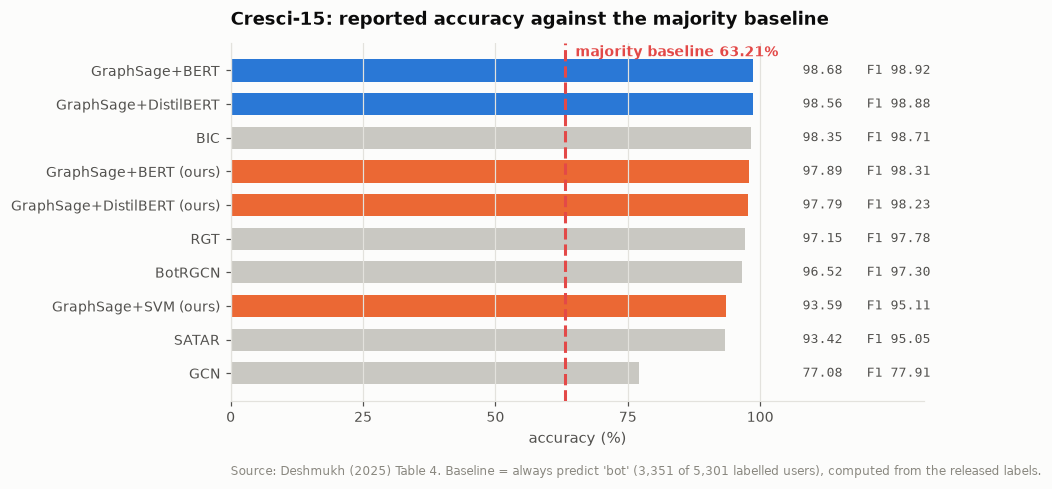

In [22]:
fig = plots.plot_table4(ours=df_rep, baseline=ds.majority_baseline()); plt.show()

---
# Part 7 — Six experiments

## 7.1 — What do the 896 dimensions contribute?

We decompose the concatenation. The two rows to watch are **raw 5 features** and
**effective 10 dims** — the input to the GraphSAGE layer, before and after
neighbourhood averaging. If `GraphSage[128]` does not beat them, the layer is a
reparameterisation rather than a feature extractor.

  raw 5 features             dim    5  acc 0.8976+/-0.0116  f1 0.9236  (baseline 0.6321)
  effective 10 dims [x || mean N(v)] dim   10  acc 0.9262+/-0.0110  f1 0.9441  (baseline 0.6321)


  GraphSage[128]             dim  128  acc 0.9359+/-0.0063  f1 0.9511  (baseline 0.6321)


  BERT[768] only             dim  768  acc 0.9730+/-0.0039  f1 0.9784  (baseline 0.6321)


  raw 5 + BERT[768]          dim  773  acc 0.9764+/-0.0035  f1 0.9811  (baseline 0.6321)


  GraphSage[128] + BERT[768] = 896 dim  896  acc 0.9779+/-0.0054  f1 0.9823  (baseline 0.6321)


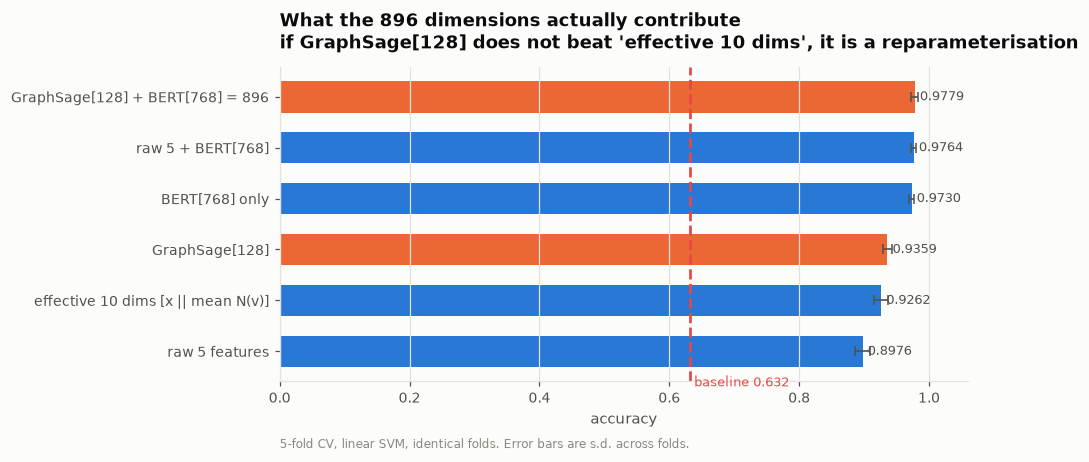

In [23]:
from botsage.experiments import suite_ablation

rows = suite_ablation(ds, Config(), text_embeddings=te_distil, quiet=False)
df_abl = results_to_frame(rows)
fig = plots.plot_ablation(df_abl, baseline=ds.majority_baseline()); plt.show()

Read the ladder:

- **5 raw numbers alone** already reach ~0.90 — against a 0.63 baseline.
- Adding the neighbourhood mean (10 dims) gains ~0.03.
- The 128-dim projection gains another ~0.01 over that. *(Hold that thought.)*
- **BERT alone** reaches ~0.97 — more than everything the graph branch offers.
- The full 896-dim vector reaches ~0.978.

So the ~0.978 headline decomposes as: BERT does almost all of it, five metadata
numbers add a little, and the graph structure adds almost nothing on top.

## 7.2 — Is `GraphSage[128]` more than its 10 inputs?

Here is the puzzle promised in Part 2. Analytically the 128-dim embedding is an
affine image of the 10-dim input, so a linear SVM cannot extract more from it.
Empirically, at `C=1`, it scores about a point higher.

Both cannot be true — unless the difference is not about *information*.

It isn't. **L2 regularisation is not invariant under a change of basis.** The
random projection spreads 10 informative directions over 128 coordinates, and
per-coordinate standardisation then rescales them, which preconditions the
penalty differently. The fix is to test at weaker penalties: as $C \to \infty$
the solution approaches the unregularised one, which *is* basis-independent, so
the gap must vanish if and only if the information is the same.

In [24]:
from botsage.experiments import suite_regularization_equivalence

rows = suite_regularization_equivalence(ds, Config(), quiet=False)
df_reg = pd.DataFrame(rows)

  C=0.001    10-dim 0.8249  SAGE-128 0.8581  delta +0.0332
  C=0.01     10-dim 0.8738  SAGE-128 0.8885  delta +0.0147


  C=0.1      10-dim 0.9055  SAGE-128 0.9195  delta +0.0140


  C=1        10-dim 0.9262  SAGE-128 0.9359  delta +0.0096


  C=10       10-dim 0.9408  SAGE-128 0.9432  delta +0.0025


  C=100      10-dim 0.9442  SAGE-128 0.9445  delta +0.0004


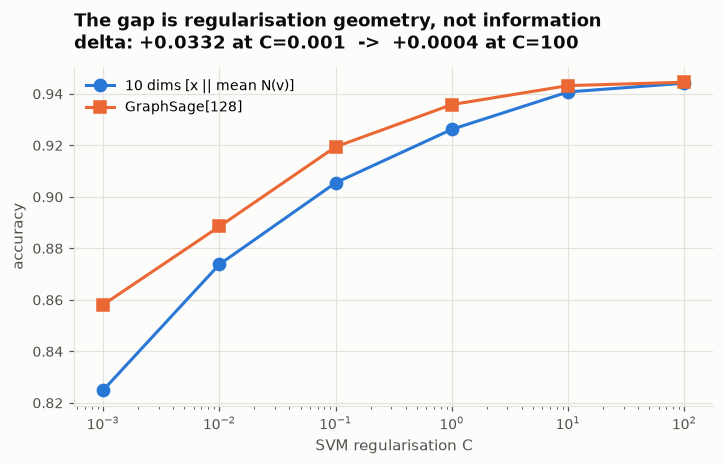

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(df_reg["C"], df_reg["acc_10dim"], "o-", label="10 dims [x || mean N(v)]",
        color=plots.SERIES[0])
ax.plot(df_reg["C"], df_reg["acc_sage128"], "s-", label="GraphSage[128]",
        color=plots.ACCENT)
ax.set_xscale("log"); ax.set_xlabel("SVM regularisation C")
ax.set_ylabel("accuracy"); ax.legend()
ax.set_title("The gap is regularisation geometry, not information\n"
             f"delta: {df_reg['delta'].iloc[0]:+.4f} at C=0.001  ->  "
             f"{df_reg['delta'].iloc[-1]:+.4f} at C=100")
plt.show()

**Monotone to zero: +0.0332 → +0.0004.** At `C=100` the two are identical to
four decimal places.

That settles it. The 128-dimensional GraphSAGE embedding contains **exactly**
the information in `[x_v ‖ mean of N(v)]`, as the algebra says it must. Its
apparent advantage at the default `C` is an artefact of how the penalty
interacts with the basis.

## 7.3 — Does the random initialisation matter?

The paper fixes no seed and reports none. For an untrained layer that sounds
alarming — the initialisation *is* the model. So how much does it move the
result?

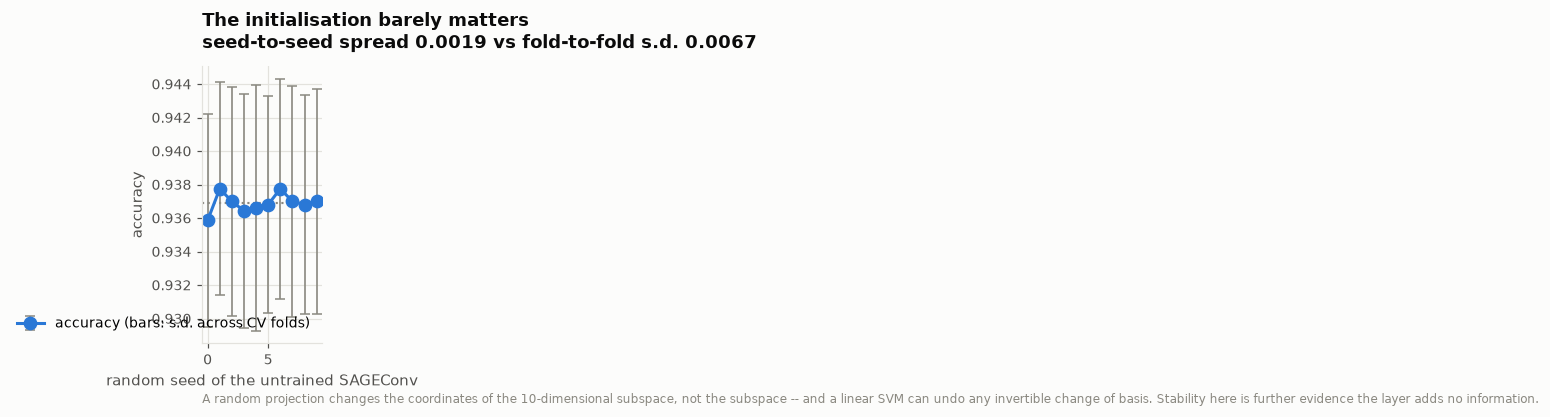

seed-to-seed spread : 0.0019
fold-to-fold s.d.   : 0.0067


In [26]:
from botsage.experiments import suite_seed_sensitivity

rows = suite_seed_sensitivity(ds, Config(), seeds=range(10), quiet=True)
df_seed = results_to_frame(rows)
fig = plots.plot_seed_sensitivity(df_seed); plt.show()

print(f"seed-to-seed spread : {df_seed['accuracy'].max() - df_seed['accuracy'].min():.4f}")
print(f"fold-to-fold s.d.   : {df_seed['accuracy_std'].mean():.4f}")

Barely at all — a spread of ~0.002, several times smaller than the fold-to-fold
noise.

This is worth pausing on, because the naive expectation is the opposite. The
reason is the same algebra as 7.2: a random projection changes the *coordinates*
of the 10-dimensional subspace, not the subspace itself, and a linear SVM can
undo any invertible change of basis. **The stability is itself evidence that the
layer adds nothing** — an untrained layer that genuinely mattered would be
seed-sensitive.

## 7.4 — What does the missing prediction head cost?

Section 3.5 skipped training because there is no prediction head. Suppose we add
one and train properly. How much was given up?

There is a trap in answering this, worth naming before we run it. A trained
GraphSAGE-plus-head is a **nonlinear** model, while the paper's arm is a
**linear** SVM on a frozen embedding. Comparing them directly would confound
*the layer being trained* with *the classifier being nonlinear*. So we run three
arms, not two:

1. untrained layer + **linear SVM** — the paper;
2. untrained layer + **MLP head** — isolates the nonlinearity;
3. **trained** layer + MLP head — isolates the training.

A convenient fact makes arm 3 cheap and exact. The paper uses **one** SAGEConv
layer, and for a single layer the aggregation `mean of N(v)` does not depend on
any parameter. So a trained 1-layer SAGEConv plus head *is* an MLP on the fixed
10-dimensional `[x_v ‖ mean N(v)]` — the same model, trained the same way, but
fitted on a 5,301 × 10 matrix instead of 3,000 full passes over a 1.29M-node
graph.

                                  variant  accuracy  accuracy_std       f1
untrained SAGEConv[128] + SVM (the paper)  0.935862      0.006349 0.951052
       untrained SAGEConv[128] + MLP head  0.977488      0.005091 0.982222
             trained SAGEConv[128] + head  0.973905      0.004933 0.979515


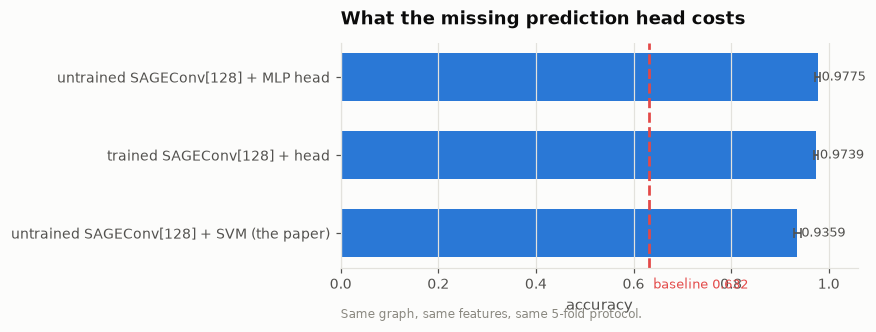

In [27]:
# This one is slow -- 3 seeds x 5 folds x 200 epochs of full-graph
# forward/backward over 1.29M nodes -- so it is read from the precomputed run.
# Uncomment to retrain from scratch (~40 min).
from botsage.config import RESULTS

p = RESULTS / "results_trained.csv"
if p.exists():
    df_tr = pd.read_csv(p)
else:
    from botsage.experiments import suite_trained_vs_untrained
    df_tr = results_to_frame(suite_trained_vs_untrained(ds, Config(), quiet=False))

print(df_tr[["variant", "accuracy", "accuracy_std", "f1"]].to_string(index=False))
fig = plots.plot_trained_vs_untrained(df_tr, baseline=ds.majority_baseline())
plt.show()

**This does not come out where one would expect, and the three arms are what
make it legible.**

| Arm | Accuracy |
|---|---|
| untrained layer + linear SVM (the paper) | 0.9359 |
| untrained layer + **MLP head** | **0.9775** |
| **trained** layer + MLP head | 0.9739 |

Training the GraphSAGE layer is worth **nothing** — arm 3 is slightly *below*
arm 2, well within the ±0.005 fold noise. Everything is gained by arm 2, i.e. by
replacing the **linear** classifier.

So the limiting choice was not Section 3.5's untrained layer after all. It was
Section 3.7's **linear kernel**:

> SVM was initialized using a linear kernel... The models performance was
> optimized by opting to not use a kernel trick, but rather relying on the
> inherent separability in this transformed space.

There is no "transformed space" to rely on — Part 2 showed the transform is
affine, so it cannot make anything linearly separable that was not already. The
five metadata features are simply not linearly separable, and a linear model
leaves ~4 points on the table.

And note where arm 2 lands: **0.9775, using no text at all**, against 0.9779 for
the full 896-dimensional BERT pipeline. Five metadata numbers, their
neighbourhood means, and a small MLP match the entire method.

## 7.5 — Which reading of the edge definition?

Section 3.1.1 is ambiguous about whether edges to cleaned-away users survive
(Part 5). Both readings, holding everything else fixed.

In [28]:
from botsage.experiments import suite_graph_scope

rows = suite_graph_scope(ds, Config(), quiet=False)
df_gs = results_to_frame(rows)
print(df_gs[["variant", "n_edges", "isolated_labelled",
             "median_degree_labelled", "accuracy", "accuracy_std"]].to_string(index=False))

  edges=all                  dim    ?  acc 0.9359+/-0.0063  f1 0.9511  (baseline 0.6321)


  edges=labelled             dim    ?  acc 0.9293+/-0.0063  f1 0.9461  (baseline 0.6321)
       variant  n_edges  isolated_labelled  median_degree_labelled  accuracy  accuracy_std
     edges=all  6994858                  0                   317.0  0.935862      0.006349
edges=labelled     8550               3381                     0.0  0.929260      0.006303


## 7.6 — 5-fold CV against the corpus's own split

The paper evaluates by 5-fold cross-validation. The baselines it compares
against were computed on each corpus's official train/test split. Those are not
the same protocol, and on Cresci-15 we can run both.

In [29]:
from botsage.experiments import suite_protocol

rows = suite_protocol(ds, Config(), text_embeddings=te_distil, quiet=False)
print(results_to_frame(rows)[["variant", "accuracy", "f1",
                              "majority_baseline"]].to_string(index=False))

  protocol=cv                dim    ?  acc 0.9779+/-0.0054  f1 0.9823  (baseline 0.6321)


  protocol=official_split    dim    ?  acc 0.8860+/-0.0000  f1 0.9036  (baseline 0.6318)
                variant  accuracy       f1  majority_baseline
            protocol=cv  0.977929 0.982335           0.632145
protocol=official_split  0.885981 0.903633           0.631776


**A 9-point gap** — 0.978 under 5-fold CV, 0.886 under the corpus's own split.
That is far too large to ignore, so it is worth diagnosing rather than just
reporting.

The class balance is identical in both (63.2% bot), so it is not an imbalance
artefact. The split is simply **not random**: Cresci-15's official test users are
systematically *less active* than its training users.

In [30]:
from botsage.pipeline import _relabel_split, make_classifier
from sklearn.model_selection import cross_val_score

sp = _relabel_split(ds, lab)
y = ds.labels[lab]
F = ds.features[lab]
tr = np.concatenate([sp["train"], sp["val"]]); te_idx = sp["test"]

print(pd.DataFrame({
    "feature": ds.feature_names,
    "train median": np.median(F[tr], 0).round(1),
    "test median": np.median(F[te_idx], 0).round(1),
}).to_string(index=False))

# If the split were random, features could not predict which side a user is on.
member = np.zeros(len(lab), int); member[te_idx] = 1
auc = cross_val_score(make_classifier(Config()), np.log1p(np.clip(F, 0, None)),
                      member, cv=5, scoring="roc_auc").mean()
print(f"\nAUC predicting test-set membership from the 5 features: {auc:.3f}")
print("(0.5 would mean the split is random with respect to them)")

         feature  train median  test median
     tweet_count          42.0         18.0
 followers_count          18.0          8.0
 following_count         288.0        176.0
    listed_count           0.0          0.0
account_age_days         921.0        694.0

AUC predicting test-set membership from the 5 features: 0.790
(0.5 would mean the split is random with respect to them)


**AUC 0.79.** The official split holds out a distributionally different slice —
lower tweet counts, fewer followers, younger accounts. Random 5-fold CV lets a
model interpolate within one distribution; the official split asks it to
extrapolate to quieter accounts, which is the harder and more realistic task.

This matters for Table 4 the same way it matters for Table 5. The baselines the
paper is compared against — BotRGCN, RGT, BIC — are evaluated on Cresci-15's
official split. The paper's own 98.68% comes from 5-fold CV. On the evidence
here, that protocol difference is worth roughly **9 accuracy points**, which is
larger than the entire spread between the methods in Table 4.

---
# Part 8 — Table 5, and the baseline nobody computed

TwiBot-22's graph and tweets are not openly available, so we cannot rerun the
method on it. We do not need to. The finding here needs only the **released
labels**, which are exact and open.

In [31]:
report = botsage.twibot22_baseline_report()

print("TwiBot-22, from the released label.csv:\n")
for k in ["corpus", "train", "val", "test"]:
    r = report[k]
    print(f"  {k:7s} n={r['n']:>9,}  bot {r['bot']:>7,} ({r['bot_frac']:6.2%})  "
          f"majority baseline {r['majority_baseline']:.4f}")

TwiBot-22, from the released label.csv:

  corpus  n=1,000,000  bot 139,943 (13.99%)  majority baseline 0.8601
  train   n=  700,000  bot  54,586 ( 7.80%)  majority baseline 0.9220
  val     n=  200,000  bot  55,913 (27.96%)  majority baseline 0.7204
  test    n=  100,000  bot  29,444 (29.44%)  majority baseline 0.7056


**86.01% of TwiBot-22 is human.** So a classifier that ignores its input and
always answers "human" scores 0.8601.

Now compare against everything Table 5 reports. The paper evaluates by **5-fold
cross-validation over the dataset**, so 0.8601 is the number its accuracies must
clear.

In [32]:
base = report["corpus"]["majority_baseline"]
rows = []
for m, typ, acc, f1, mine in botsage.PAPER_TABLE5:
    rows.append({"method": m + (" (this paper)" if mine else ""),
                 "accuracy": acc, "F1": f1,
                 "vs 86.01% baseline": round(acc - base * 100, 2),
                 "beats baseline?": "yes" if acc / 100 > base else "NO"})
print(pd.DataFrame(rows).to_string(index=False))

                           method  accuracy    F1  vs 86.01% baseline beats baseline?
                              SVM     49.30   NaN              -36.71              NO
                              GCN     47.72 38.10              -38.29              NO
                              HGT     74.91 39.60              -11.10              NO
                          BotRGCN     79.66 57.50               -6.35              NO
                              RGT     76.47 49.24               -9.54              NO
                            BGSRD     71.88 21.14              -14.13              NO
       GraphSage+SVM (this paper)     67.21 48.32              -18.80              NO
GraphSage+DistilBERT (this paper)     74.62 51.69              -11.39              NO


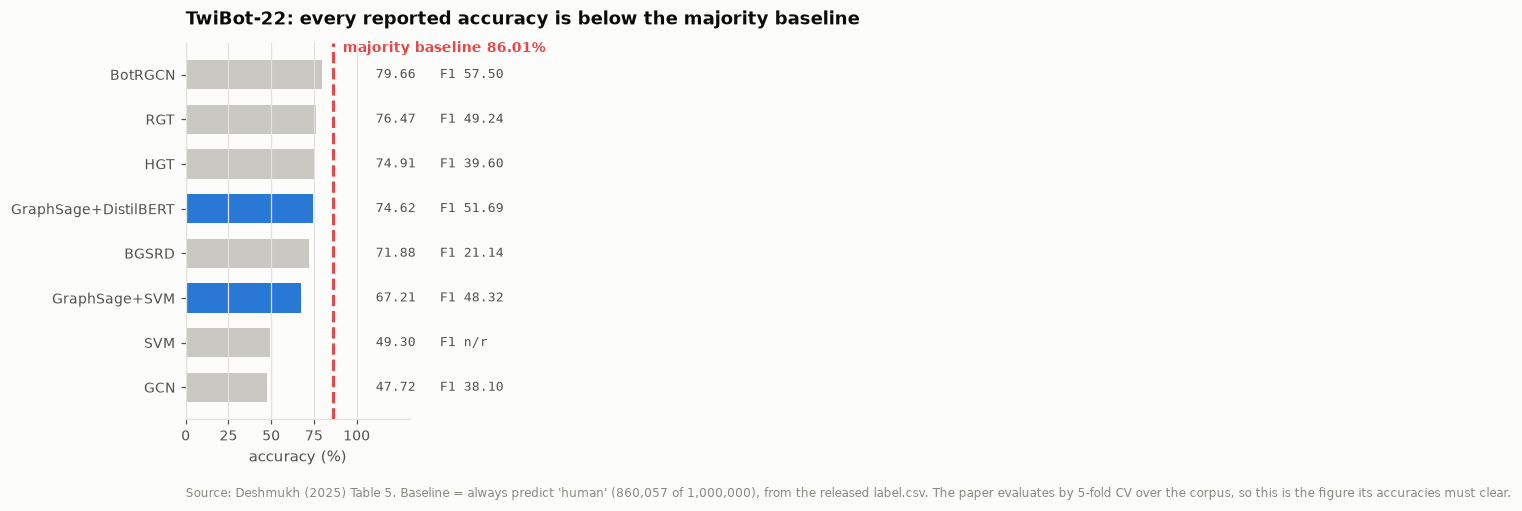

In [33]:
fig = plots.plot_table5(baseline=base); plt.show()

**Eight of eight rows fall below the trivial baseline.** Not just this paper's
74.62% — BotRGCN's 79.66%, RGT's 76.47%, every published number in the table.

### It is worse than a simple oversight

The two columns of Table 5 are not measured on the same task. TwiBot-22's
official split is **not stratified**:

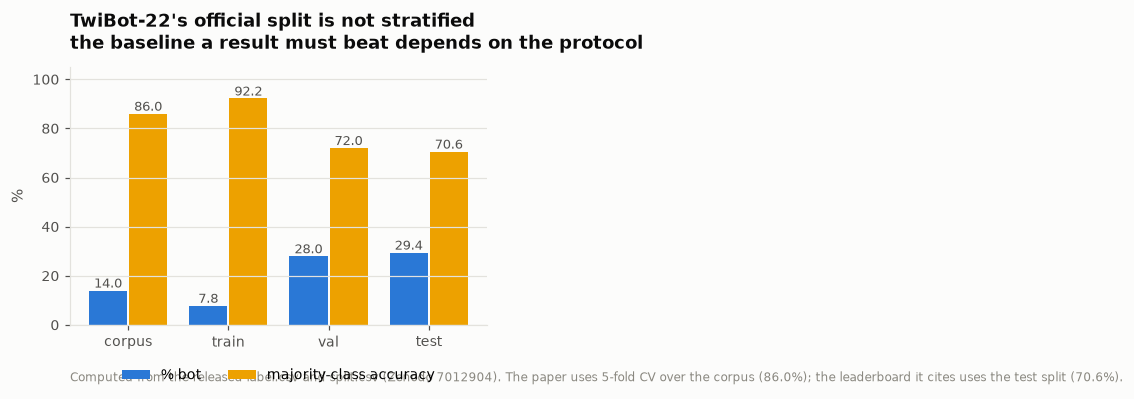

corpus-wide baseline (the paper's 5-fold CV protocol): 0.8601
official test-split baseline (the leaderboard's protocol): 0.7056


In [34]:
fig = plots.plot_twibot22_splits(report); plt.show()
print(f"corpus-wide baseline (the paper's 5-fold CV protocol): "
      f"{report['corpus']['majority_baseline']:.4f}")
print(f"official test-split baseline (the leaderboard's protocol): "
      f"{report['test']['majority_baseline']:.4f}")

The training split is 7.8% bots; the test split is 29.4%. So:

- The **baselines** in Table 5 come from the TwiBot-22 leaderboard, evaluated on
  the official test split — where the floor is **70.56%**.
- The paper's **own rows** come from 5-fold CV over the whole corpus — where the
  floor is **86.01%**.

They are placed side by side, in the same column, without comment. On its own
protocol the paper's 74.62% is 11 points *below* trivial; on the leaderboard's
protocol it would be 4 points above it. The accuracy column cannot support the
comparison drawn from it, including the paper's claim to "outperform some
state-of-the-art models".

**What should have been reported is F1**, which the table does carry and which
is not fooled by imbalance. There the paper's 51.69% against BotRGCN's 57.50% is
a meaningful, and much more modest, comparison — and the conclusion the paper
draws from Table 5 ("DistilBERT embeddings provide meaningful enhancement over
graph structural information alone", 51.69 vs 48.32 F1) survives intact.

---
# Part 9 — What we learned

## The replication succeeded

Cresci-15: we get **97.89%** (BERT) and **97.79%** (DistilBERT) against the
paper's 98.68% and 98.56% — within 0.8 points, with the BERT > DistilBERT
ordering preserved, despite differing in tokenizer batching, stop-word list, one
substituted feature, and the SVM's unreported `C`. The pipeline works as
described.

## But the credit belongs elsewhere

| Component | Cresci-15 accuracy |
|---|---|
| majority baseline | 0.632 |
| 5 metadata numbers | ~0.898 |
| + neighbourhood mean (10 dims) | ~0.926 |
| GraphSage[128] | ~0.936 |
| **BERT alone** | **~0.973** |
| full 896-dim | ~0.978 |

BERT does nearly all the work; five metadata numbers do most of the rest; the
graph adds almost nothing. And what the graph branch *does* add is not graph
learning:

1. **The layer is untrained**, so it is an affine map of ten numbers — rank
   exactly 10 of 128 (Part 2).
2. **Its apparent edge over those ten numbers is a regularisation artefact**,
   vanishing from +0.0332 to +0.0004 as the SVM penalty weakens (Part 7.2).
3. **Its random seed barely matters** (spread 0.002), because a change of basis
   is invisible to a linear model — further confirmation (Part 7.3).
4. **On Cresci-15 the graph is nearly empty anyway**: 0.12% of edges join two
   users with features, and 64% of labelled users have an exactly-zero
   neighbourhood term (Part 5).

The honest description of the method is **"DistilBERT plus five metadata
features, classified by an SVM"**. That is a perfectly good bot detector. It is
not what the title says.

## The binding constraint was the linear kernel, not the untrained layer

This is the result we did not expect. Decomposing carefully (Part 7.4):

| Arm | Accuracy |
|---|---|
| untrained layer + linear SVM (the paper) | 0.9359 |
| untrained layer + **MLP head** | **0.9775** |
| trained layer + MLP head | 0.9739 |

Training the GraphSAGE layer buys **nothing**. Replacing the *linear* SVM buys
**+4.2 points** — and gets to 0.9775 **without using any text**, essentially
matching the full 896-dimensional pipeline's 0.9779.

Section 3.7 justifies the linear kernel by "relying on the inherent separability
in this transformed space". Part 2 showed there is no transformed space: the map
is affine, so it cannot separate anything that was not already separable. That
single sentence costs more than every other design choice in the paper combined.

## Both tables are measured on a different protocol from their baselines

- **Table 5**: all eight accuracies fall below TwiBot-22's 86.01% majority
  baseline, and the paper's rows use 5-fold CV over the corpus (floor 86.01%)
  while the baselines beside them use the official test split (floor 70.56%).
- **Table 4**: the same problem, and now measurable. On Cresci-15's own split we
  score **0.886** against **0.978** under 5-fold CV — a **9-point** gap, because
  the official split holds out systematically quieter accounts (test-membership
  is predictable from the five features at AUC 0.79). The Table 4 baselines —
  BotRGCN, RGT, BIC — use that official split.

Nine points is larger than the entire spread between the methods in Table 4. The
claim to "outperform all other models on the Cresci-15 dataset" is not supported
by a like-for-like comparison.

F1 is the metric that survives both problems, and the paper's qualitative
conclusion from Table 5 — that DistilBERT embeddings help over graph structure
alone, 51.69 vs 48.32 — holds.

## What would make this work stronger

Each follows directly from a finding above, and none is expensive:

- **Drop the linear kernel.** An RBF SVM or a two-layer MLP on the *same*
  features is worth ~4 accuracy points — more than BERT adds (Part 7.4).
- **Report the majority baseline**, and prefer F1 or balanced accuracy on
  TwiBot-22.
- **Use each corpus's official split** when comparing against numbers computed
  on it. Worth ~9 points on Cresci-15 (Part 7.6).
- **Check graph connectivity before trusting a graph model** — a one-line
  statistic would have shown 64% of Cresci-15 nodes have no usable neighbours.
- **Report the SVM's `C`**; it moves accuracy from 0.825 to 0.944 across its
  range, far more than any architectural choice here.
- **Train the layer, or drop it.** Untrained, it is a random reparameterisation
  of five numbers; those five numbers can be fed to the classifier directly.

## Reproducing everything

```bash
P=01-info-propagation/bot-detection-paper/.venv/bin/python

bash scripts/get_bot_data.sh                                  # ~2.5 GB
$P scripts/prepare_bot_embeddings.py --model distilbert-base-uncased
$P scripts/prepare_bot_embeddings.py --model bert-base-uncased
$P scripts/run_botsage.py --quiet                             # checks + figures
$P scripts/run_botsage.py --quiet --experiments               # + the SVM runs
$P scripts/build_botsage_notebook.py                          # regenerate this
```

`replication.ipynb` is a **build artefact** of `scripts/build_botsage_notebook.py`.
Edit the builder, not the notebook.

## Files

| Path | Contents |
|---|---|
| `botsage/sage.py` | `SAGEConv` matching PyG, plus `TrainedSAGE` |
| `botsage/checks.py` | The seven property checks of Part 2 |
| `botsage/data.py` | Cresci-15, TwiBot-20, TwiBot-22 loaders |
| `botsage/text.py` | Sects. 3.1.2 and 3.2 — cleaning and embedding |
| `botsage/pipeline.py` | Concatenation, SVM, 5-fold protocol |
| `botsage/experiments.py` | The six suites of Part 7 |
| `botsage/plots.py` | Every figure |
| `docs/DISCREPANCIES_BOTSAGE.md` | **Read before changing `sage.py`** |